# 프로젝트
- 00 약품 처방 건수 예측하기
- 파일명 : drugs.csv

In [3]:
import pandas as pd 

df = pd.read_csv('./data/drugs.csv')
df.head()

,ds,y
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


## 시각화

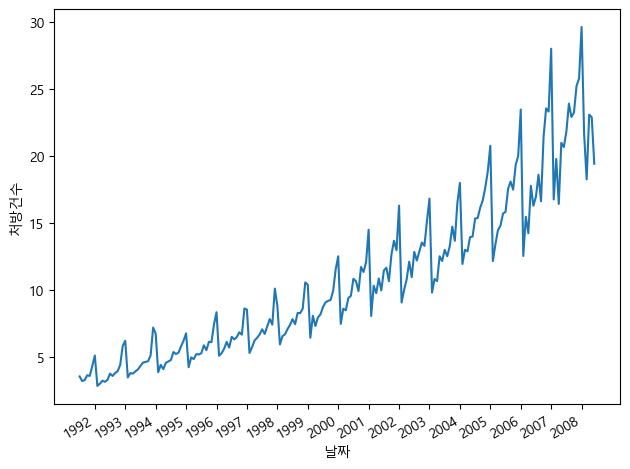

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 한글출력
plt.rcParams['font.family'] = 'Malgun Gothic' #  Windows 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

fig, ax = plt.subplots()

ax.plot(df.y)
ax.set_xlabel('날짜')
ax.set_ylabel('처방건수')

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 미션 및 절차
- 주어진 데이터를 기반으로 향후 12개월의 롤링 예측을 수행한다.
- 시계열 분해
- 적합한 모델 결정
- 정상성 결정
- 차분 결정
- 최적의(p,d,q)(P,D,Q)m 매개변수 찾기
- 잔차분석 모델 검증

In [10]:
# 필요한 라이브러리 임포트
from sklearn.metrics import mean_squared_error, mean_absolute_error  # 모델 평가 지표
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # ACF, PACF 시각화
from statsmodels.tsa.seasonal import seasonal_decompose, STL  # 계절성 분해
from statsmodels.stats.diagnostic import acorr_ljungbox  # 잔차 검정
from statsmodels.tsa.statespace.sarimax import SARIMAX  # SARIMA 모델
from statsmodels.tsa.arima_process import ArmaProcess  # ARMA 프로세스
from statsmodels.graphics.gofplots import qqplot  # Q-Q plot
from statsmodels.tsa.stattools import adfuller  # 정상성 검정
from tqdm.auto import tqdm  # 진행률 표시
from itertools import product  # 파라미터 조합 생성
from typing import Union  # 타입 힌팅

# 기본 데이터 분석 및 시각화 라이브러리
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# Jupyter notebook에서 그래프 인라인 표시
%matplotlib inline

### 시각화

### 시계열 분해

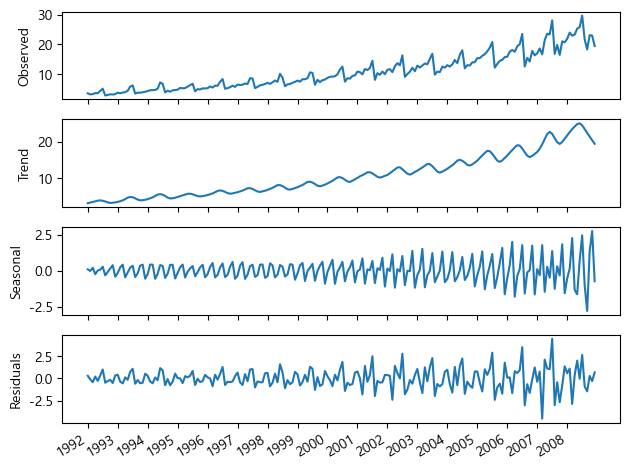

In [27]:
advanced_decomposition = STL(df.y, period=4).fit()
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True)

ax1.plot(advanced_decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(advanced_decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(advanced_decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(advanced_decomposition.resid)
ax4.set_ylabel('Residuals')


plt.xticks(np.arange(0, 204, 12), [1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 모델링

### 정상성 확인

In [33]:
from statsmodels.tsa.stattools import adfuller

ad_fuller_result = adfuller(df['y'])
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p_value: {ad_fuller_result[1]}')

ADF Statistic: 3.145185689306735
p_value: 1.0


### 1차 차분

In [34]:
df_diff = np.diff(df['y'], n=1)
ad_fuller_result = adfuller(df_diff)
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p_value: {ad_fuller_result[1]}')

ADF Statistic: -2.495172147449726
p_value: 0.11665341686469105


### 1차 계절 차분

In [35]:
df_diff_seasonal_diff = np.diff(df_diff, n=12)
ad_fuller_result = adfuller(df_diff_seasonal_diff)
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p_value: {ad_fuller_result[1]}')

ADF Statistic: -19.848440098002758
p_value: 0.0


### 훈련데이터와 테스트 데이터 구분

### SARIMA(p,1,q)(P,1,Q)<sub>12<sub> 

### 잔차 분석